# Communities and Crime — evaluacija i poređenje

Ova sveska:
1. Učitava sve rezultate klasterovanja
2. Pravi sveobuhvatnu tabelu poređenja metrika
3. Vizuelizuje poređenje metrika po algoritmima i skupovima karakteristika
4. Interpretira klastere — kakve zajednice su završile u kojoj grupi?

> **Napomena:** prvo pokrenuti sveske **`01`** i **`02`**.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
import joblib
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.figsize'] = (13, 6)
plt.rcParams['figure.dpi'] = 120

print('Libraries loaded.')

Libraries loaded.


## 1. Učitavanje podataka i rezultata klasterovanja

In [4]:
X_full    = pd.read_csv('data_preprocessed.csv')
X_imputed = pd.read_csv('data_imputed.csv')
X_pca70   = pd.read_csv('data_pca_70.csv')
X_pca80   = pd.read_csv('data_pca_80.csv')
X_econ    = pd.read_csv('data_economic.csv')
targets   = pd.read_csv('data_targets.csv')

kmeans_results  = joblib.load('results_kmeans.pkl')
agg_results     = joblib.load('results_agglomerative.pkl')
dbscan_results  = joblib.load('results_dbscan.pkl')
clarans_results = joblib.load('results_clarans.pkl')
birch_results   = joblib.load('results_birch.pkl')
cure_results    = joblib.load('results_cure.pkl')

pca_viz = PCA(n_components=2, random_state=42)
X_viz = pca_viz.fit_transform(X_full)

results_df = pd.read_csv('clustering_results.csv')
print(f'Loaded {len(results_df)} algorithm-feature configurations.')
results_df.head()

Loaded 21 algorithm-feature configurations.


,Algorithm,Feature Set,n_clusters,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,K-Means,Full,3,0.1777,1.7846,370.6
1,K-Means,PCA-70,3,0.2686,1.3279,606.3
2,K-Means,PCA-80,3,0.2277,1.5045,502.4
3,K-Means,Economic,3,0.2065,1.6030,720.4
4,Agglomerative (Ward),Full,3,0.1604,1.8891,324.6


## 2. Tabelarni prikaz poređenja metrika

- **Silueta koeficijent** [-1, 1]: što je veći, to je bolje. Meri koliko je tačka slična svom klasteru u poređenju sa ostalima.
- **Davies-Bouldinov indeks** [0, ∞): što je manji, to je bolje. Predstavlja odnos raspršenosti unutar klastera i razdvojenosti između klastera.
- **Calinski-Harabasz indeks** [0, ∞): što je veći, to je bolje. Predstavlja odnos disperzije između klastera i disperzije unutar klastera.

In [5]:
print('=== All Configurations — Sorted by Silhouette Score ===')
pd.set_option('display.max_rows', 60)
pd.set_option('display.float_format', '{:.4f}'.format)
results_df.sort_values('Silhouette', ascending=False)

=== All Configurations — Sorted by Silhouette Score ===


,Algorithm,Feature Set,n_clusters,Silhouette,Davies-Bouldin,Calinski-Harabasz
19,CURE,PCA-80,3,0.7504,0.2869,93.0000
20,CURE,Economic,3,0.6796,0.3130,47.9000
18,CURE,PCA-70,3,0.6561,0.4540,110.1000
8,DBSCAN,PCA-70,3,0.5612,0.6230,62.3000
1,K-Means,PCA-70,3,0.2686,1.3279,606.3000
15,BIRCH,PCA-70,3,0.2429,1.4122,540.3000
5,Agglomerative (Ward),PCA-70,3,0.2325,1.4068,504.6000
2,K-Means,PCA-80,3,0.2277,1.5045,502.4000
13,CLARANS,Economic,3,0.2153,1.6814,611.0000
7,Agglomerative (Ward),Economic,3,0.2118,1.6467,608.0000


In [11]:
print('=== Top 5 by Silhouette ===')
top5_sil = results_df.dropna(subset=['Silhouette']).sort_values('Silhouette', ascending=False).head(5)
print(top5_sil[['Algorithm', 'Feature Set', 'n_clusters', 'Silhouette', 'Davies-Bouldin', 'Calinski-Harabasz']].to_string(index=False))

print('\n=== Top 5 by Davies-Bouldin ===')
top5_db = results_df.dropna(subset=['Davies-Bouldin']).sort_values('Davies-Bouldin').head(5)
print(top5_db[['Algorithm', 'Feature Set', 'n_clusters', 'Silhouette', 'Davies-Bouldin', 'Calinski-Harabasz']].to_string(index=False))

print('\n=== Top 5 by Calinski-Harabasz ===')
top5_ch = results_df.dropna(subset=['Calinski-Harabasz']).sort_values('Calinski-Harabasz', ascending=False).head(5)
print(top5_ch[['Algorithm', 'Feature Set', 'n_clusters', 'Silhouette', 'Davies-Bouldin', 'Calinski-Harabasz']].to_string(index=False))

=== Top 5 by Silhouette ===
Algorithm Feature Set  n_clusters  Silhouette  Davies-Bouldin  Calinski-Harabasz
     CURE      PCA-80           3      0.7504          0.2869            93.0000
     CURE    Economic           3      0.6796          0.3130            47.9000
     CURE      PCA-70           3      0.6561          0.4540           110.1000
   DBSCAN      PCA-70           3      0.5612          0.6230            62.3000
  K-Means      PCA-70           3      0.2686          1.3279           606.3000

=== Top 5 by Davies-Bouldin ===
Algorithm Feature Set  n_clusters  Silhouette  Davies-Bouldin  Calinski-Harabasz
     CURE      PCA-80           3      0.7504          0.2869            93.0000
     CURE    Economic           3      0.6796          0.3130            47.9000
     CURE      PCA-70           3      0.6561          0.4540           110.1000
   DBSCAN      PCA-70           3      0.5612          0.6230            62.3000
   DBSCAN      PCA-80           7      0.0393   

## 3. Vizuelizacija poređenja

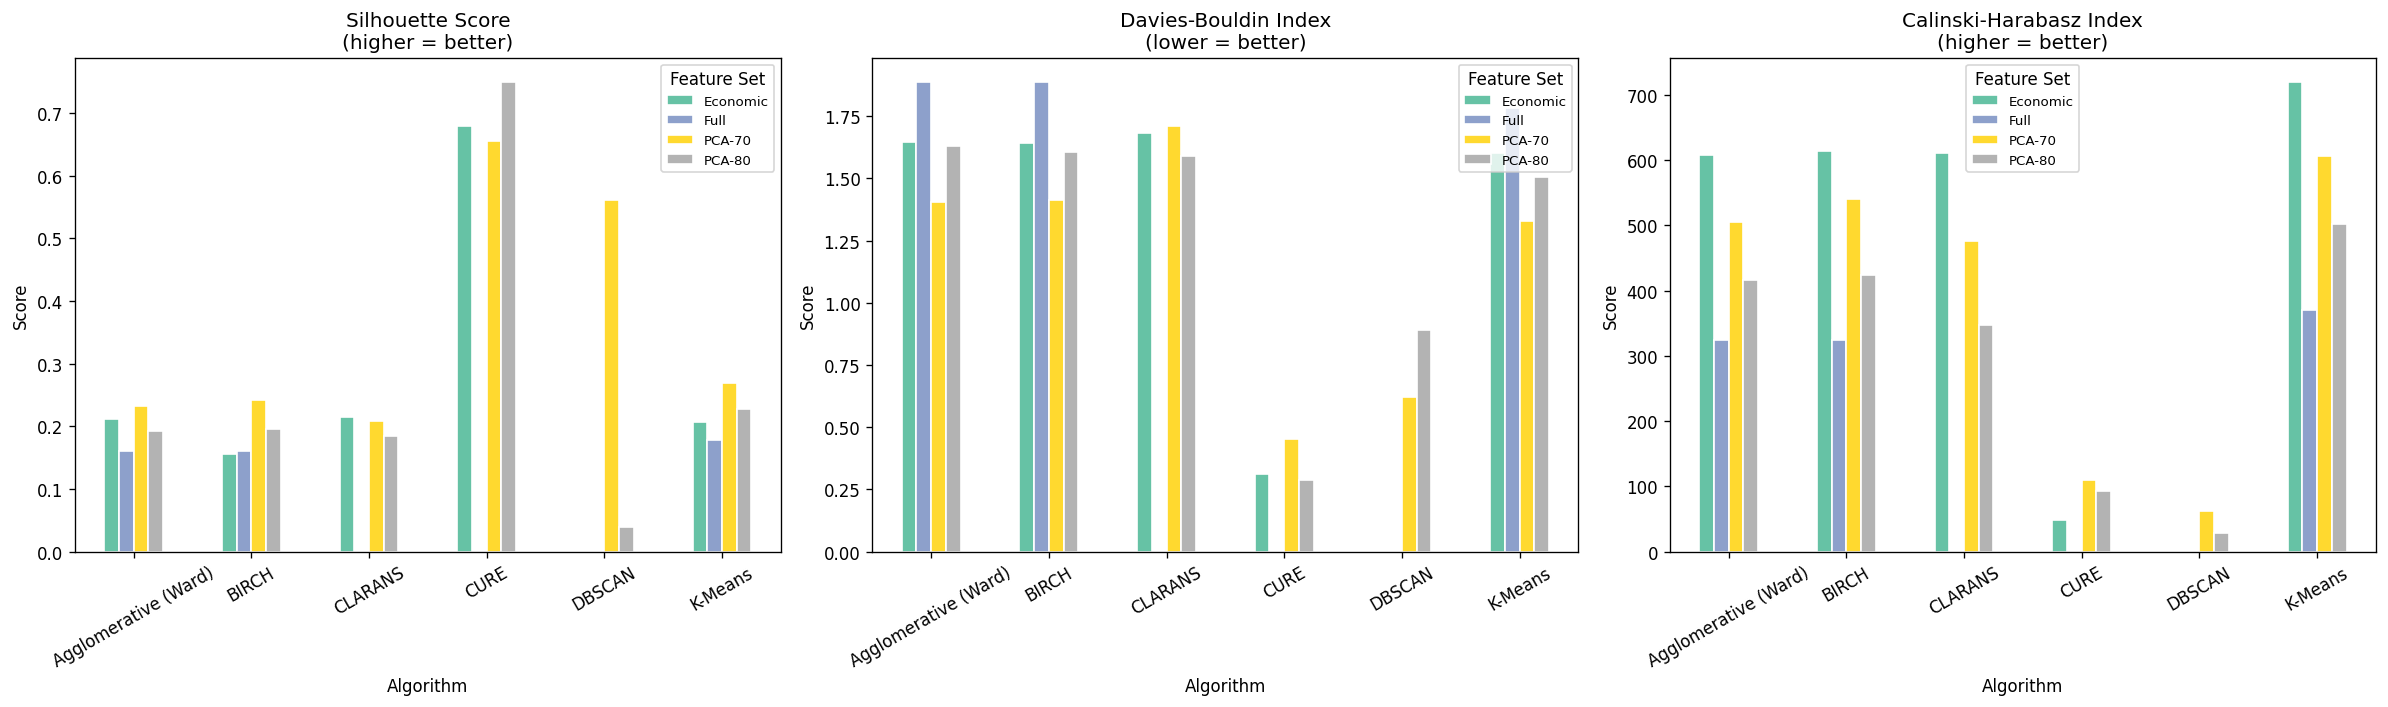

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

pivot_sil = results_df.pivot_table(values='Silhouette', index='Algorithm', columns='Feature Set')
pivot_sil.plot(kind='bar', ax=axes[0], colormap='Set2', edgecolor='white')
axes[0].set_title('Silhouette Score\n(higher = better)', fontsize=12)
axes[0].set_ylabel('Score')
axes[0].legend(fontsize=8, title='Feature Set')
axes[0].tick_params(axis='x', rotation=30)

pivot_db = results_df.pivot_table(values='Davies-Bouldin', index='Algorithm', columns='Feature Set')
pivot_db.plot(kind='bar', ax=axes[1], colormap='Set2', edgecolor='white')
axes[1].set_title('Davies-Bouldin Index\n(lower = better)', fontsize=12)
axes[1].set_ylabel('Score')
axes[1].legend(fontsize=8, title='Feature Set')
axes[1].tick_params(axis='x', rotation=30)

pivot_ch = results_df.pivot_table(values='Calinski-Harabasz', index='Algorithm', columns='Feature Set')
pivot_ch.plot(kind='bar', ax=axes[2], colormap='Set2', edgecolor='white')
axes[2].set_title('Calinski-Harabasz Index\n(higher = better)', fontsize=12)
axes[2].set_ylabel('Score')
axes[2].legend(fontsize=8, title='Feature Set')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('figures/metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

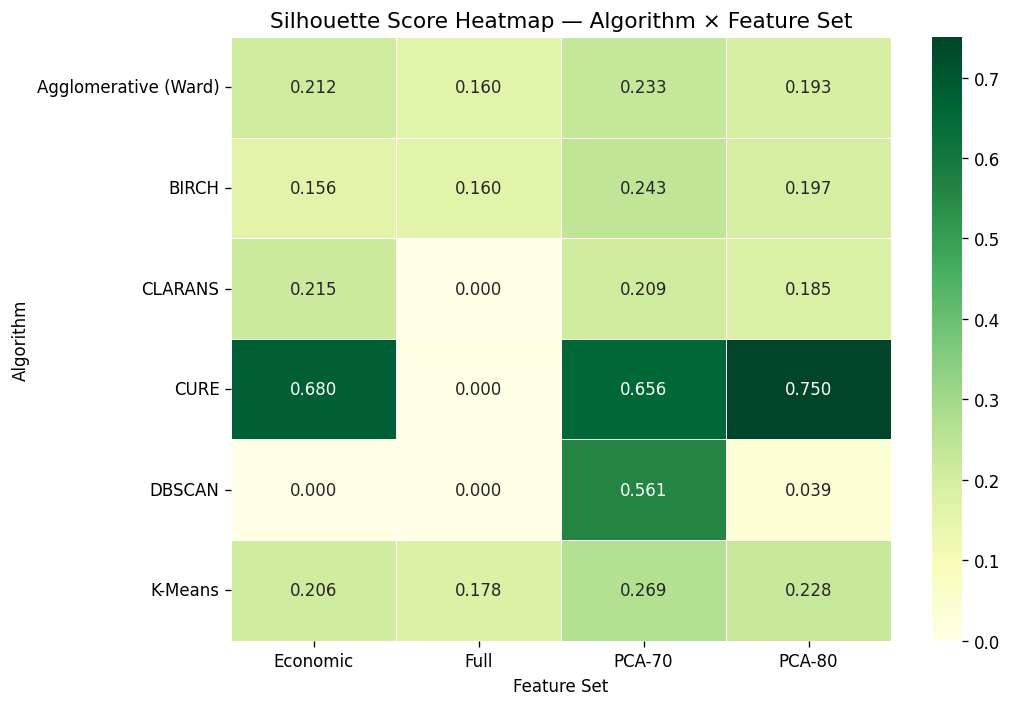

In [13]:
plt.figure(figsize=(9, 6))
sns.heatmap(
    pivot_sil.fillna(0), annot=True, fmt='.3f', cmap='YlGn',
    linewidths=0.5, annot_kws={'size': 10}
)
plt.title('Silhouette Score Heatmap — Algorithm × Feature Set', fontsize=13)
plt.tight_layout()
plt.savefig('figures/silhouette_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Najbolji algoritam — vizuelizacija klastera

In [14]:
best_row = results_df.dropna(subset=['Silhouette']).sort_values('Silhouette', ascending=False).iloc[0]
print(f'Best algorithm: {best_row["Algorithm"]}')
print(f'Feature set:    {best_row["Feature Set"]}')
print(f'Silhouette:     {best_row["Silhouette"]:.4f}')
print(f'Davies-Bouldin: {best_row["Davies-Bouldin"]:.4f}')
print(f'n_clusters:     {int(best_row["n_clusters"])}')

Best algorithm: CURE
Feature set:    PCA-80
Silhouette:     0.7504
Davies-Bouldin: 0.2869
n_clusters:     3


In [15]:
algo = best_row['Algorithm']
fs   = best_row['Feature Set']

if algo == 'K-Means':
    best_labels = kmeans_results[fs]['labels']
elif algo == 'Agglomerative (ward)':
    best_labels = agg_results[f'ward_{fs}']['labels']
elif algo == 'CLARANS':
    best_labels = clarans_results[fs]['labels']
elif algo == 'BIRCH':
    best_labels = birch_results[fs]['labels']
elif algo == 'DBSCAN':
    key = f'best_{fs}'
    best_labels = dbscan_results.get(key, dbscan_results[list(dbscan_results.keys())[-1]])['labels']
elif algo == 'CURE':
    best_labels = cure_results[fs]['labels']
else:
    best_labels = kmeans_results['Full']['labels']

print(f'Labels shape: {best_labels.shape}')
print(f'Unique clusters: {sorted(set(best_labels))}')

Labels shape: (2215,)
Unique clusters: [np.int64(0), np.int64(1), np.int64(2)]


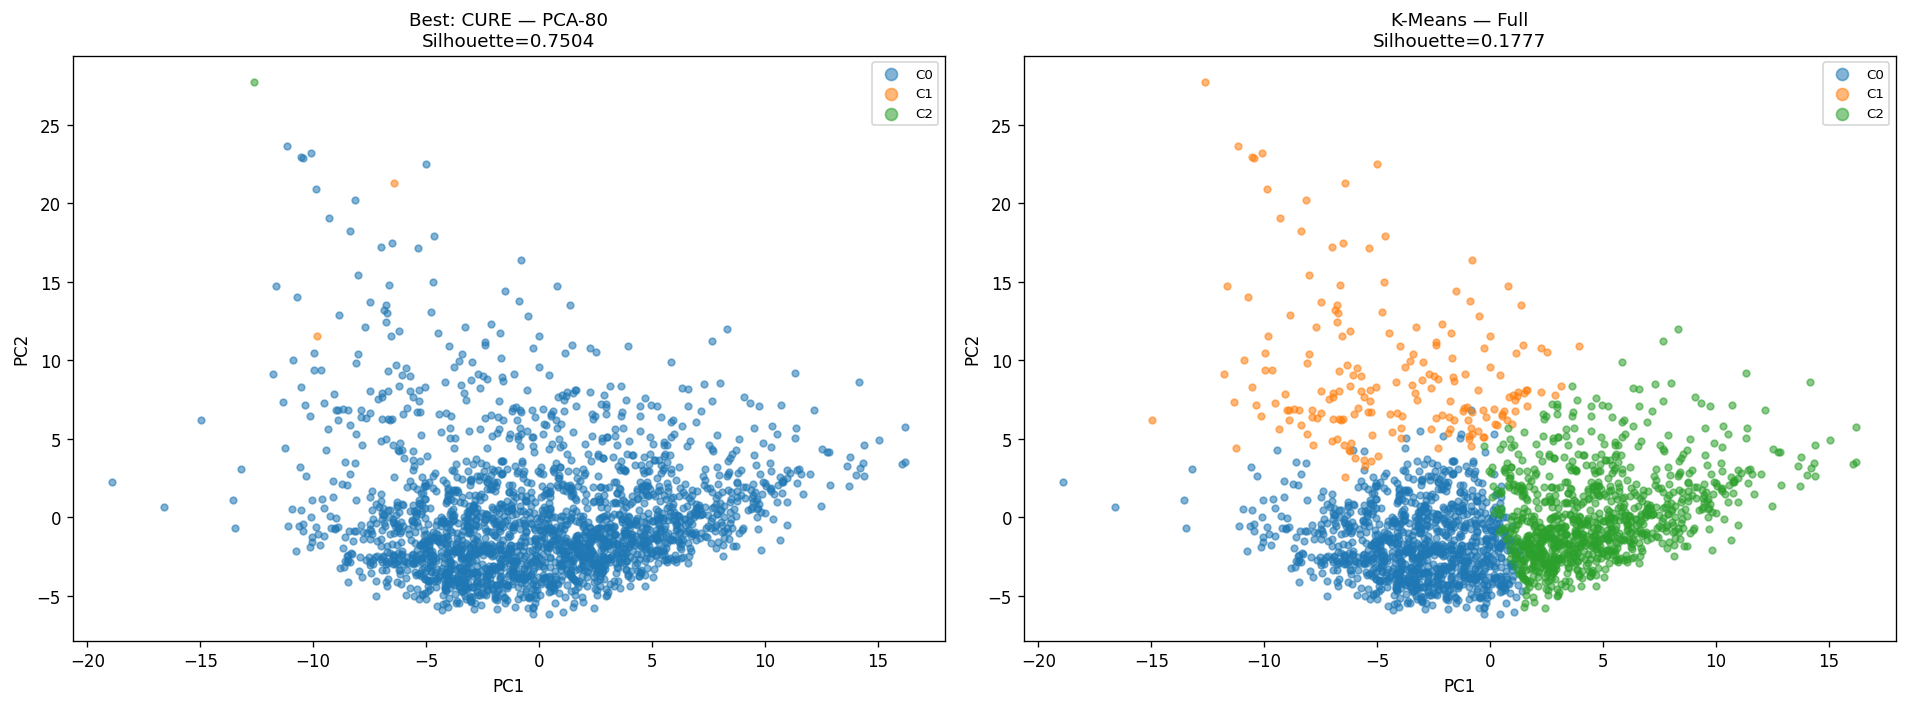

In [16]:
km_full_labels = kmeans_results['Full']['labels']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

unique = sorted(set(best_labels))
palette = sns.color_palette('tab10', n_colors=max(len(unique), 1))
for i, lbl in enumerate(unique):
    mask = best_labels == lbl
    c = 'lightgray' if lbl == -1 else palette[i % len(palette)]
    axes[0].scatter(X_viz[mask, 0], X_viz[mask, 1], c=[c], label=f'C{lbl}' if lbl != -1 else 'Noise', alpha=0.55, s=16)
axes[0].set_title(f'Best: {algo} — {fs}\nSilhouette={best_row["Silhouette"]:.4f}', fontsize=11)
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[0].legend(fontsize=8, markerscale=1.8)

unique2 = sorted(set(km_full_labels))
for i, lbl in enumerate(unique2):
    mask = km_full_labels == lbl
    c = palette[i % len(palette)]
    axes[1].scatter(X_viz[mask, 0], X_viz[mask, 1], c=[c], label=f'C{lbl}', alpha=0.55, s=16)
km_sil = results_df[(results_df['Algorithm']=='K-Means') & (results_df['Feature Set']=='Full')]['Silhouette'].values[0]
axes[1].set_title(f'K-Means — Full\nSilhouette={km_sil:.4f}', fontsize=11)
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
axes[1].legend(fontsize=8, markerscale=1.8)

plt.tight_layout()
plt.savefig('figures/best_vs_kmeans.png', dpi=150, bbox_inches='tight')
plt.show()